In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
X = df.drop(columns=['math_score'])

In [7]:
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [8]:
Y = df['math_score']

In [9]:
Y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [17]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

numeric_transformer = StandardScaler()
obj_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",obj_transformer,cat_features),
        ("StandardScaler", numeric_transformer,num_features)
    ]
)

In [18]:
X = preprocessor.fit_transform(X)

In [19]:
X.shape

(1000, 19)

In [21]:
X_train,X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=34)

In [22]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [26]:
def evaluate_model(true_val,pred_value):
    mae = mean_absolute_error(true_val,pred_value)
    mse = mean_squared_error(true_val,pred_value)
    rmse = np.sqrt(mse)
    r2_score_val = r2_score(true_val,pred_value)
    return mae,rmse,r2_score_val

In [28]:
models = {
    "Linear Regression" : LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "Addaboost regressor": AdaBoostRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(),
}

model_list = []
r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]

    model.fit(X_train,Y_train)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(Y_train,Y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(Y_test,Y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for training set')
    print("-Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print('-'*35)
    print('\n')

Linear Regression
Model performance for training set
-Root Mean Squared Error: 5.3211
- Mean Absolute Error: 4.2422
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3696
- Mean Absolute Error: 4.2404
- R2 Score: 0.8835
-----------------------------------


Ridge
Model performance for training set
-Root Mean Squared Error: 5.3213
- Mean Absolute Error: 4.2399
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3749
- Mean Absolute Error: 4.2470
- R2 Score: 0.8832
-----------------------------------


Lasso
Model performance for training set
-Root Mean Squared Error: 6.5440
- Mean Absolute Error: 5.1622
- R2 Score: 0.8099
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.8874
- Mean Absolute Error: 5.4851
- R2 Score: 0.8083
-----------------------------------


KNN
Model performance for training set
-Root Mean Squared 

In [29]:
res = pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2_Score'])

In [30]:
res

,Model,R2_Score
0,Linear Regression,0.883475
1,Ridge,0.883243
2,Lasso,0.808283
3,KNN,0.787768
4,RandomForestRegressor,0.841981
5,Addaboost regressor,0.824949
6,Decision Tree,0.729360
7,XGBRegressor,0.812878
8,CatBoosting Regressor,0.866556


<Axes: xlabel='Model', ylabel='R2_Score'>

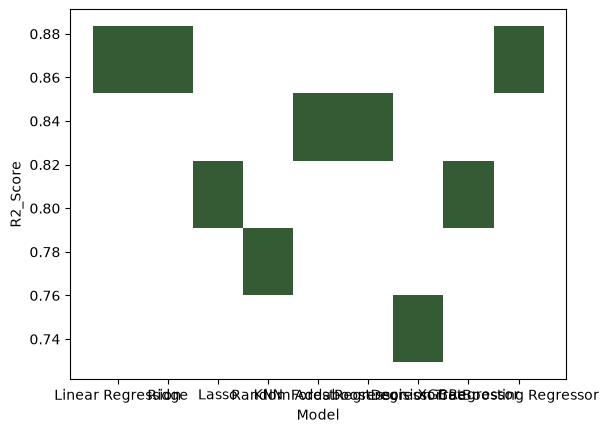

In [38]:
# plt.plot(figsize=(20,20))
sns.histplot(data=res, x='Model',y='R2_Score',kde=True,color='g')

In [39]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,Y_train)
Y_pred = lin_model.predict(X_test)
score = r2_score(Y_test,Y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.35


Text(0, 0.5, 'Predicted')

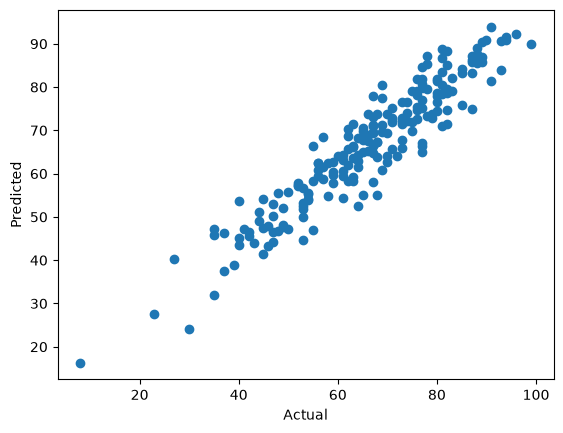

In [40]:
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

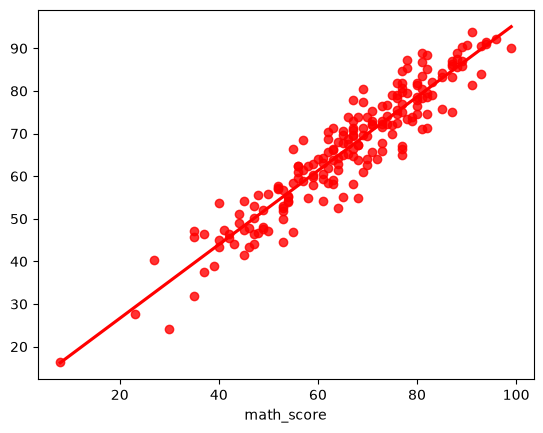

In [41]:
sns.regplot(x=Y_test,y=Y_pred,ci=None,color='red')